### **Part 1 - Definition and Visualization of Brownian Motion**

A stochastic process $\{W_t\}_{t \geq 0}$ is a **standard Brownian motion**
(or Wiener process) if it satisfies the following four conditions:

1. **Initial condition:** $W_0 = 0$
2. **Independent increments:** for $0 \leq s < t$, the increment $W_t - W_s$
   is independent of $\mathcal{F}_s = \sigma(W_u : u \leq s)$
3. **Stationary Gaussian increments:** for $0 \leq s < t$,
$$
W_t - W_s \sim \mathcal{N}(0,\, t - s)
$$
4. **Continuous paths:** $t \mapsto W_t$ is continuous almost surely

From condition 3, setting $s = 0$:
$$
W_t \sim \mathcal{N}(0, t), \qquad \mathbb{E}[W_t] = 0, \qquad \text{Var}(W_t) = t
$$

This is the continuous-time analogue of $\mathbb{E}[X_n] = 0$, $\text{Var}(X_n) = n$
from the random walk — with discrete steps $n$ replaced by continuous time $t$.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.prop_cycle': plt.cycler(color=[
        '#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'
    ]),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size': 12,
})

np.random.seed(42)

We simulate BM by discretizing $[0, T]$ into $n$ equal intervals of width
$\Delta t = T/n$. Over each interval the increment is:
$$
\Delta W_i = W_{t_{i+1}} - W_{t_i} \sim \mathcal{N}(0,\, \Delta t)
$$

and the path is recovered by cumulative summation:
$$
W_{t_k} = \sum_{i=1}^{k} \Delta W_i
$$

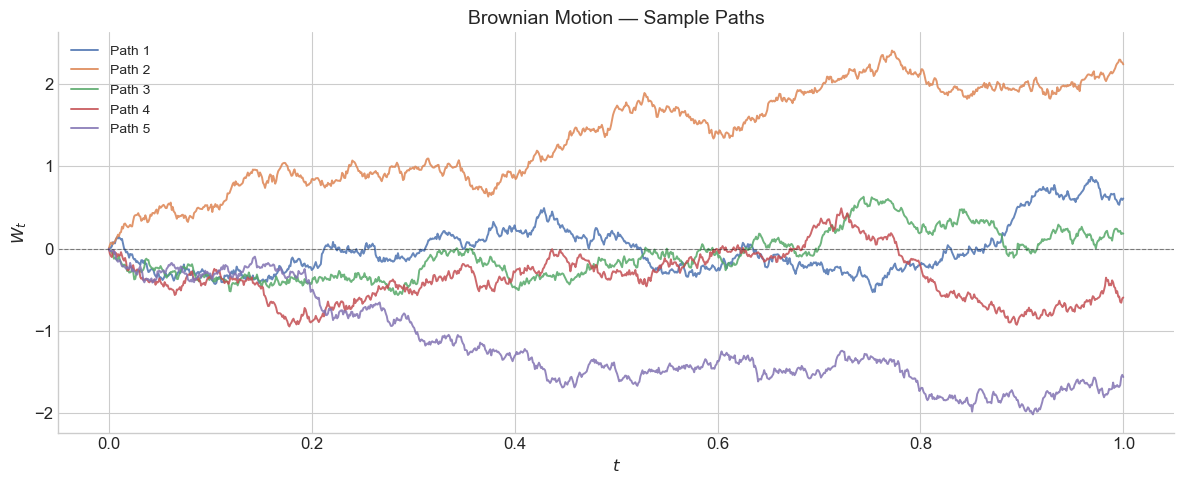

In [4]:
def simulate_bm(T=1.0, n_steps=1000, n_paths=1, seed=None): 
    # Parameters:
    # T : float, time horizon
    # n_steps : int, number of discretization steps
    # n_paths : int, number of independent paths
    # seed : int, random seed

    # Returns
    # t : (n_steps+1,) time grid
    # paths : (n_paths, n_steps+1) array of BM paths
    
    if seed is not None:
        np.random.seed(seed)
    dt = T / n_steps
    dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, n_steps))
    W = np.cumsum(dW, axis=1)
    W = np.hstack([np.zeros((n_paths, 1)), W])  # W_0 = 0
    t = np.linspace(0, T, n_steps + 1)
    return t, W

n_paths = 5
t, paths = simulate_bm(T=1.0, n_steps=1000, n_paths=n_paths, seed=42)

fig, ax = plt.subplots(figsize=(12, 5))
for i, path in enumerate(paths):
    ax.plot(t, path, linewidth=1.4, alpha=0.85, label=f'Path {i+1}')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_xlabel('$t$')
ax.set_ylabel('$W_t$')
ax.set_title('Brownian Motion — Sample Paths', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### **Part 2 - Brownian Motion vs. Random Walk**
The most immediate visual difference between BM and the random walk is **path regularity**.   
RW can only jump +1 or -1 at each step. BM paths are continuous: there are no jumps, no matter how finely you zoom in.

We make this concrete by plotting a single rescaled random walk path and a single BM path side by side, then zooming into a short segment of each. The random walk reveals its discrete steps; the BM path remains smooth but irregular at every scale.

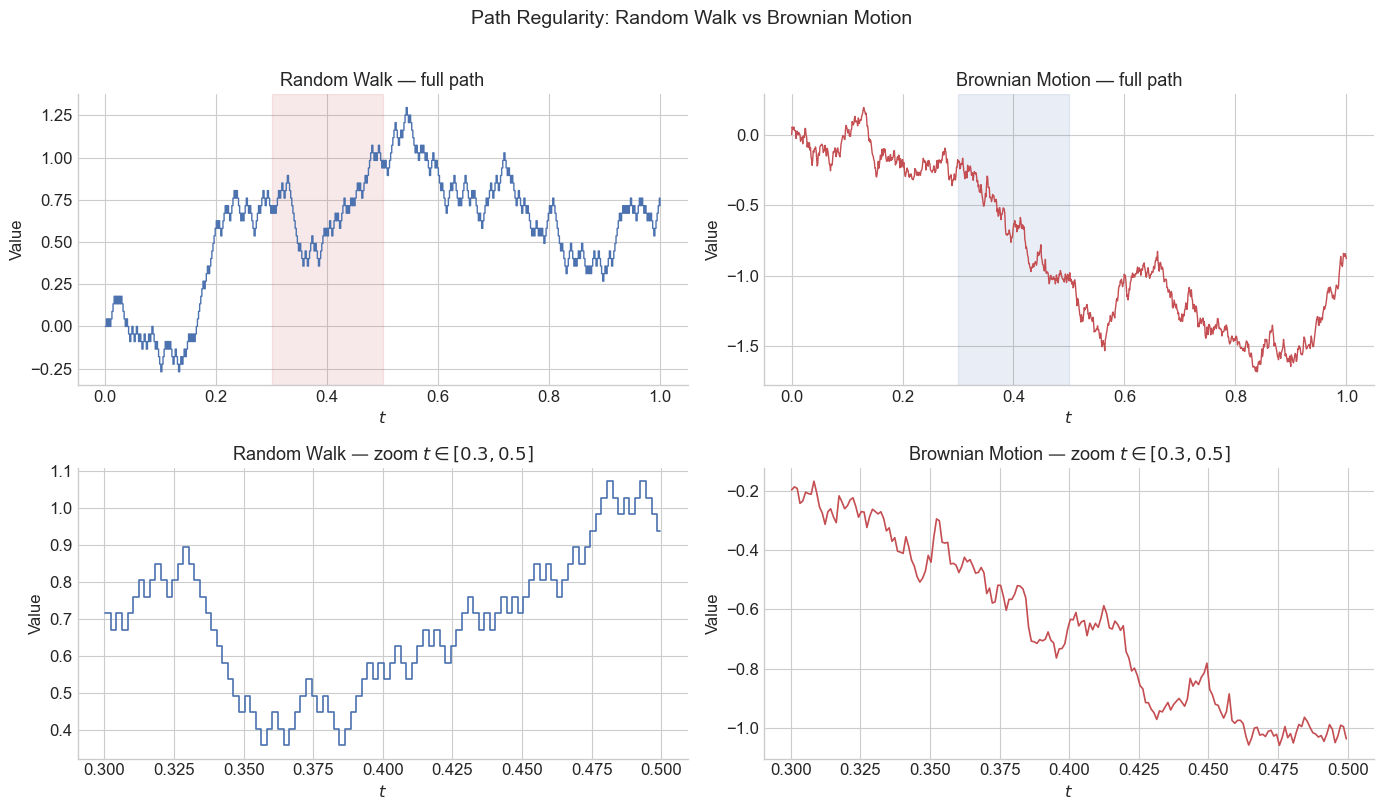

In [5]:
np.random.seed(7)
n = 500
t_fine = np.linspace(0, 1, 1000)

# Rescaled RW on the same fine grid
steps = np.random.choice([-1, 1], size=n)
X = np.concatenate([[0], np.cumsum(steps)])
idx = np.floor(t_fine * n).astype(int)
rw = X[idx] / np.sqrt(n)

# BM on the same grid
t_bm, bm_paths = simulate_bm(T=1.0, n_steps=999, n_paths=1, seed=7)
bm = bm_paths[0]

# Zoom window
zoom_lo, zoom_hi = 0.3, 0.5
mask_rw = (t_fine >= zoom_lo) & (t_fine <= zoom_hi)
mask_bm = (t_bm >= zoom_lo) & (t_bm <= zoom_hi)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Full RW
axes[0,0].step(t_fine, rw, where='post', color='#4C72B0', linewidth=1.0)
axes[0,0].axvspan(zoom_lo, zoom_hi, alpha=0.12, color='#C44E52')
axes[0,0].set_title('Random Walk — full path', fontsize=13)
axes[0,0].set_xlabel('$t$'); axes[0,0].set_ylabel('Value')

# Zoomed RW
axes[1,0].step(t_fine[mask_rw], rw[mask_rw], where='post',
               color='#4C72B0', linewidth=1.2)
axes[1,0].set_title(f'Random Walk — zoom $t \\in [{zoom_lo}, {zoom_hi}]$', fontsize=13)
axes[1,0].set_xlabel('$t$'); axes[1,0].set_ylabel('Value')

# Full BM
axes[0,1].plot(t_bm, bm, color='#C44E52', linewidth=1.0)
axes[0,1].axvspan(zoom_lo, zoom_hi, alpha=0.12, color='#4C72B0')
axes[0,1].set_title('Brownian Motion — full path', fontsize=13)
axes[0,1].set_xlabel('$t$'); axes[0,1].set_ylabel('Value')

# Zoomed BM
axes[1,1].plot(t_bm[mask_bm], bm[mask_bm], color='#C44E52', linewidth=1.2)
axes[1,1].set_title(f'Brownian Motion — zoom $t \\in [{zoom_lo}, {zoom_hi}]$', fontsize=13)
axes[1,1].set_xlabel('$t$'); axes[1,1].set_ylabel('Value')
fig.suptitle('Path Regularity: Random Walk vs Brownian Motion', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Random Walk Converging to Brownian Motion**

**Donsker’s theorem:** 
a properly rescaled random walk converges to Brownian motion as the number of steps goes to infinity.

Consider a simple symmetric random walk:

$$
X_n = \sum_{i=1}^n x_i,
\qquad
x_i \in \{-1,+1\}
$$

with equal probability.

To compare it with Brownian motion on the interval $[0,1]$, we rescale both time and space:

$$
W_n(t)
=
\frac{X_{\lfloor nt \rfloor}}{\sqrt n},
\qquad t\in[0,1]
$$

This scaling is crucial:

- Time is accelerated by a factor of $n$
- Space is compressed by a factor of $\sqrt n$

The rescaled process has:
$$
E[W_n(t)] = 0,
\qquad
\mathrm{Var}(W_n(t)) \approx t
$$
which matches the variance structure of Brownian motion:
$$
W_t \sim \mathcal N(0,t)
$$
As $n$ increases, the random walk paths become increasingly fine and begin to resemble the rough continuous behavior of Brownian motion.

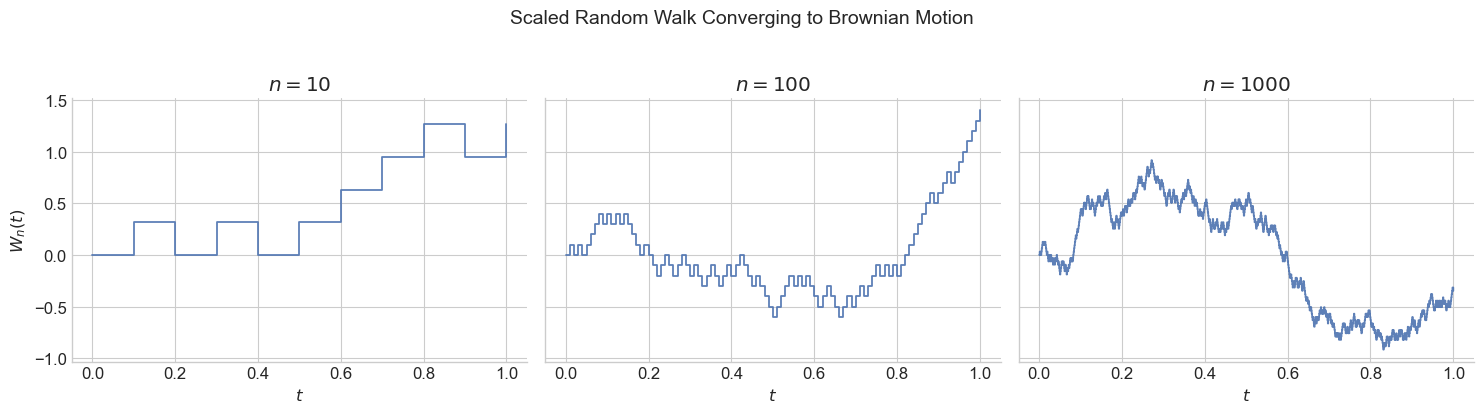

In [6]:
def rescaled_rw(n, seed=None):

    if seed is not None:
        np.random.seed(seed)
    steps = np.random.choice([-1, 1], size=n)
    X = np.concatenate([[0], np.cumsum(steps)])
    t = np.linspace(0, 1, n + 1)
    return t, X / np.sqrt(n)

ns = [10, 100, 1000]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, n in zip(axes, ns):
    t, rw = rescaled_rw(n, seed=7)
    ax.step(
        t,
        rw,
        where='post',
        linewidth=1.3,
        alpha=0.9
    )

    ax.set_title(f'$n = {n}$')
    ax.set_xlabel('$t$')

    if ax is axes[0]:
        ax.set_ylabel(r'$W_n(t)$')

fig.suptitle(
    r'Scaled Random Walk Converging to Brownian Motion',
    fontsize=14,
    y=1.03
)

plt.tight_layout()
plt.show()

### **Part 3 - Properties of Brownian Motion**  
**1. self-similarity**: zooming into any segment reveals the same irregular structure at every scale. This is because BM is nowhere differentiable, meaning that there is no scale at which the path looks locally like a straight line.

Formally, BM satisfies the **scaling property**:
$$
\{W_{ct}\}_{t \geq 0} \overset{d}{=} \{\sqrt{c}\, W_t\}_{t \geq 0}
\quad \text{for any } c > 0
$$

meaning a time-scaled BM is statistically identical to a space-scaled BM. 
The three panels below zoom into successive segments of the same path. Each looks statistically indistinguishable from the others.

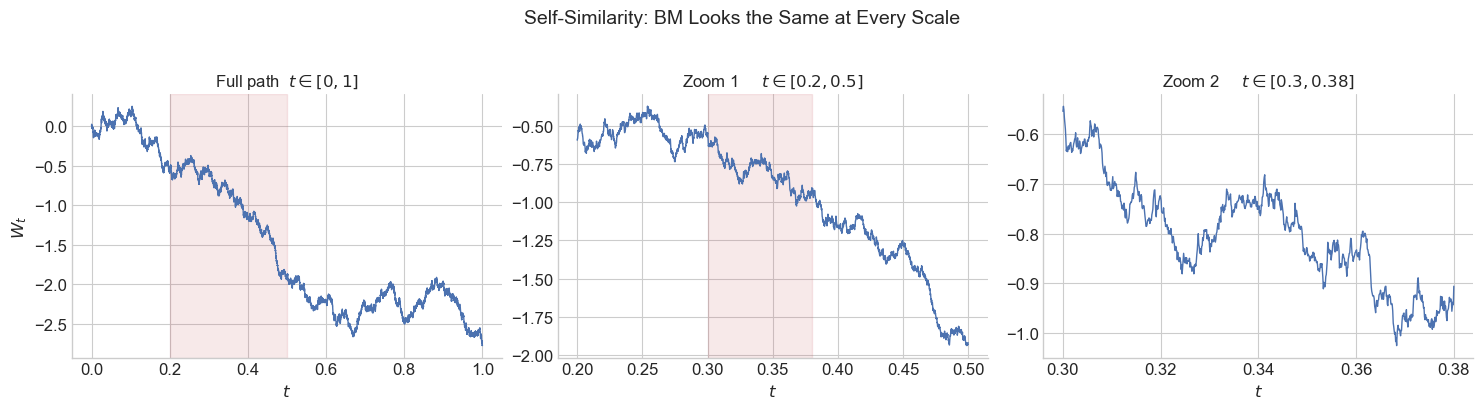

In [27]:
t_full, bm_full = simulate_bm(T=1.0, n_steps=10_000, n_paths=1, seed=3)
bm_full = bm_full[0]

# Three successive zoom windows
windows = [(0.0, 1.0), (0.2, 0.5), (0.3, 0.38)]
labels = ['Full path  $t \\in [0, 1]$',
           'Zoom 1     $t \\in [0.2, 0.5]$',
           'Zoom 2     $t \\in [0.3, 0.38]$']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (lo, hi), label in zip(axes, windows, labels):
    mask = (t_full >= lo) & (t_full <= hi)
    ax.plot(t_full[mask], bm_full[mask], color='#4C72B0', linewidth=1.0)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('$t$')
    if ax is axes[0]:
        ax.set_ylabel('$W_t$')
    # Highlight next zoom window on the current panel
    if lo == 0.0:
        ax.axvspan(0.2, 0.5,  alpha=0.12, color='#C44E52')
    elif lo == 0.2:
        ax.axvspan(0.3, 0.38, alpha=0.12, color='#C44E52')

fig.suptitle('Self-Similarity: BM Looks the Same at Every Scale', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**2. Independent Increments**  

non-overlapping increments are independent. For
$0 \leq s < t < u < v$:
$$
(W_t - W_s) \perp (W_v - W_u)
$$

We verify this empirically: if increments are truly independent, their
correlation should be zero. We compute the correlation between increments
over $[0, 0.25]$ and $[0.5, 0.75]$ across many simulated paths.

Correlation between non-overlapping increments: 0.0056  (theory = 0)


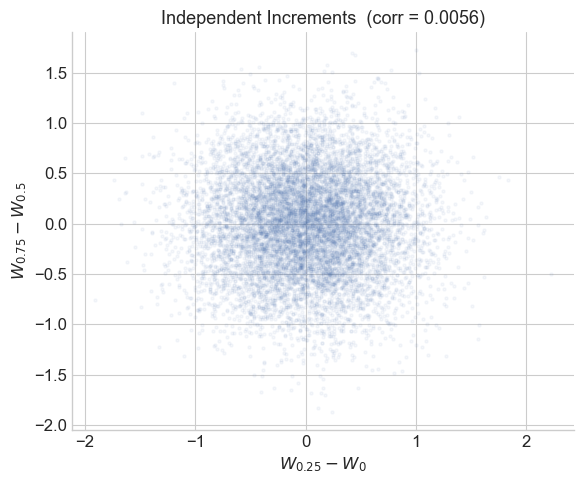

In [28]:
_, paths_inc = simulate_bm(T=1.0, n_steps=1000, n_paths=10_000, seed=0)

# Increment over [0, 0.25]: index 0 to 250
# Increment over [0.5, 0.75]: index 500 to 750
inc1 = paths_inc[:, 250] - paths_inc[:, 0]
inc2 = paths_inc[:, 750] - paths_inc[:, 500]

corr = np.corrcoef(inc1, inc2)[0, 1]
print(f"Correlation between non-overlapping increments: {corr:.4f}  (theory = 0)")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(inc1, inc2, alpha=0.05, s=5, color='#4C72B0')
ax.set_xlabel('$W_{0.25} - W_0$')
ax.set_ylabel('$W_{0.75} - W_{0.5}$')
ax.set_title(f'Independent Increments  (corr = {corr:.4f})', fontsize=13)
plt.tight_layout()
plt.show()

**3. Variance Proportional to Time**  
From the definition, $\text{Var}(W_t) = t$. This means the uncertainty in the process's position grows linearly with time. Same as Random Walk, the standard deviation grows as $\sqrt{t}$.  
We verify this empirically across many paths.

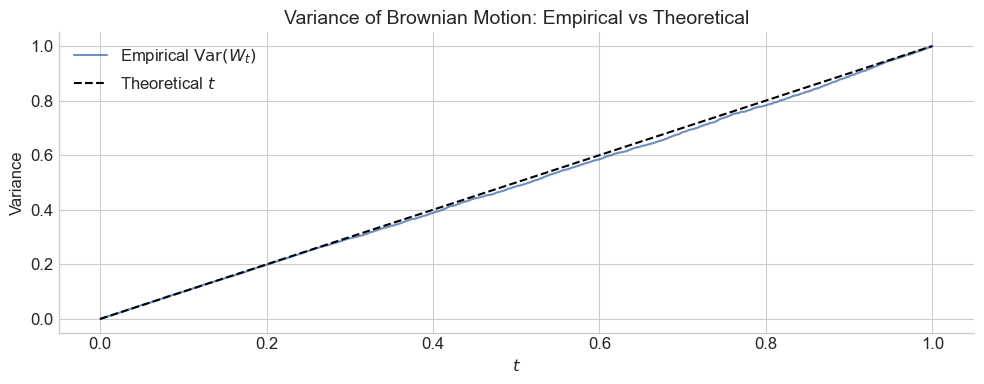

In [29]:
_, paths_var = simulate_bm(T=1.0, n_steps=1000, n_paths=10_000, seed=1)

empirical_var = paths_var.var(axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, empirical_var, alpha=0.8, linewidth=1.5,
        label='Empirical $\\mathrm{Var}(W_t)$')
ax.plot(t, t, 'k--', linewidth=1.5, label='Theoretical $t$')
ax.set_xlabel('$t$')
ax.set_ylabel('Variance')
ax.set_title('Variance of Brownian Motion: Empirical vs Theoretical', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

## Summary

| Property | Random Walk $X_n$ | Brownian Motion $W_t$ |
|---|---|---|
| Time | Discrete $n \in \mathbb{N}$ | Continuous $t \geq 0$ |
| Increment distribution | $\pm 1$ equally likely | $\mathcal{N}(0, \Delta t)$ |
| Mean | $\mathbb{E}[X_n] = 0$ | $\mathbb{E}[W_t] = 0$ |
| Variance | $\text{Var}(X_n) = n$ | $\text{Var}(W_t) = t$ |
| Increments | Independent | Independent |
| Path regularity | Discrete jumps of $\pm 1$ | Continuous, nowhere differentiable |
